# Four Runners

## A story built from 80,000 simulated runners

This notebook asks two questions. First: what separates a fast runner from a slow one in this
dataset? Second: can this dataset answer that at all? Sections 1 to 4 answer the first question.
Section 5 answers the second, and changes what the first four mean.

> **SIMULATED POPULATION** — Every number in this notebook comes from a synthetic dataset
> (Kaggle, 80,000 rows), not real racers. Two things to keep in mind while reading: these are
> descriptions of the dataset, never advice for a runner, and every number is marked as simulated
> so it doesn't get mistaken for a fact about real marathons.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

plt.style.use('seaborn-v0_8-whitegrid')
# a family LIST (not the sans-serif preference list) is what enables per-glyph fallback,
# so the VO2 subscript still renders where Arial has no glyph for it
plt.rcParams['font.family'] = ['Arial', 'DejaVu Sans']
COLORS = {0: '#5B8FF9', 1: '#61DDAA', 2: '#F6BD16', 3: '#E8684A'}
NAME_MAP = {0: 'Newcomers', 1: 'Regulars', 2: 'Naturals', 3: 'Veterans'}
INK = '#273142'

def find_data_dir():
    for candidate in [Path('../data'), Path('data')]:
        if (candidate / 'clean.csv').exists() and (candidate / 'profiles.csv').exists():
            return candidate
    raise FileNotFoundError('Could not find data/clean.csv and data/profiles.csv')

DATA = find_data_dir()
FIG = DATA.parent / 'figures'
clean = pd.read_csv(DATA / 'clean.csv')
profiles = pd.read_csv(DATA / 'profiles.csv')
df = clean.merge(profiles, on='runner_id', how='inner', validate='one_to_one')
df['profile_name'] = df['profile'].map(NAME_MAP)
d = df[df.dnf == 0].copy()

assert len(df) == 80_000
assert df['profile'].nunique() == 4
print(f'{len(df):,} simulated runners | {df["profile"].nunique()} descriptive profiles | {len(d):,} finishers')

80,000 simulated runners | 4 descriptive profiles | 78,011 finishers


## 1. Meet four runners

At the starting line, **80,000 simulated runners** look like they're all preparing for the same
race. Their preparation tells four different stories.

The largest group is the **Newcomers** — **44% of this simulated population**. They've been
running for about **21 months**, run less often than the others, and **7 in 10 follow a beginner
training plan**. On average they finish in about **301 minutes** — just over five hours.

The **Regulars** make up **25% of the simulated runners**. They run often — about **5.2 times a
week** — but each run tends to be short, so their weekly distance stays low. They finish in about
**292 minutes** on average.

The **Naturals**, **16% of the simulated population**, stand out for their bodies rather than
their training: their average aerobic fitness score (VO&#8322; max) is about **65**, well above
the rest, while everything else about their training is fairly ordinary. They finish in about
**283 minutes**.

The **Veterans**, **15% of the simulated runners**, have been running the longest — about **95
months** — cover the most distance each week (around **22 miles**), do the most speed training,
and mostly follow an advanced plan (**85%**). They're the fastest group, finishing in about **250
minutes** on average — four hours and ten.

These are four labels we gave to four regions, not four kinds of runner. The lines between them
are a choice we made, not a fact about the runners — draw the groups a different way and the split
looks noticeably different. Up close, the four profiles blend into each other.

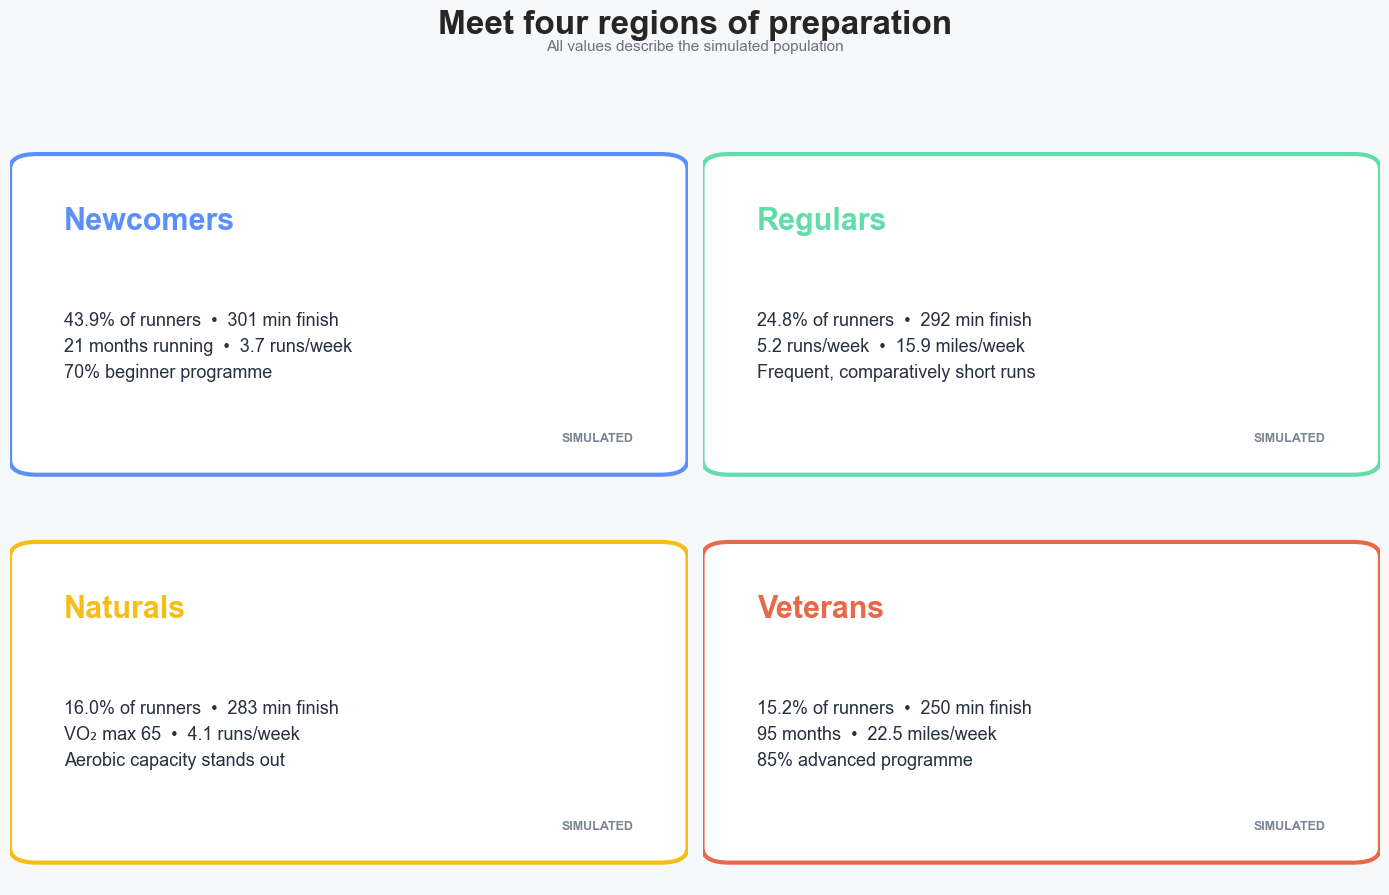

In [2]:
profile_stats = (
    df.groupby(['profile', 'profile_name'], as_index=False)
      .agg(
          runners=('runner_id', 'size'),
          experience_months=('running_experience_months', 'mean'),
          runs_per_week=('runs_per_week', 'mean'),
          weekly_miles=('weekly_mileage_miles', 'mean'),
          vo2_max=('vo2_max', 'mean'),
          speed_sessions=('speed_work_sessions_per_week', 'mean'),
          finish_minutes=('actual_finish_time_minutes', 'mean'),
          dnf_rate=('dnf', 'mean'),
      )
      .sort_values('profile')
)
profile_stats['share'] = profile_stats['runners'] / len(df) * 100
programme = pd.crosstab(df['profile'], df['training_program'], normalize='index') * 100

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.patch.set_facecolor('#F7F8FA')

descriptions = {
    0: lambda r: f"{r.share:.1f}% of runners  \u2022  {r.finish_minutes:.0f} min finish\n{r.experience_months:.0f} months running  \u2022  {r.runs_per_week:.1f} runs/week\n{programme.loc[0, 'Beginner']:.0f}% beginner programme",
    1: lambda r: f"{r.share:.1f}% of runners  \u2022  {r.finish_minutes:.0f} min finish\n{r.runs_per_week:.1f} runs/week  \u2022  {r.weekly_miles:.1f} miles/week\nFrequent, comparatively short runs",
    2: lambda r: f"{r.share:.1f}% of runners  \u2022  {r.finish_minutes:.0f} min finish\nVO\u2082 max {r.vo2_max:.0f}  \u2022  {r.runs_per_week:.1f} runs/week\nAerobic capacity stands out",
    3: lambda r: f"{r.share:.1f}% of runners  \u2022  {r.finish_minutes:.0f} min finish\n{r.experience_months:.0f} months  \u2022  {r.weekly_miles:.1f} miles/week\n{programme.loc[3, 'Advanced']:.0f}% advanced programme",
}

for ax, row in zip(axes.flat, profile_stats.itertuples()):
    ax.set_facecolor('#F7F8FA')
    ax.axis('off')
    card = FancyBboxPatch((0.02, 0.08), 0.96, 0.82,
                          boxstyle='round,pad=0.02,rounding_size=0.04',
                          transform=ax.transAxes, facecolor='white',
                          edgecolor=COLORS[row.profile], linewidth=3)
    ax.add_patch(card)
    ax.text(0.08, 0.72, row.profile_name, transform=ax.transAxes,
            fontsize=22, fontweight='bold', color=COLORS[row.profile])
    ax.text(0.08, 0.50, descriptions[row.profile](row), transform=ax.transAxes,
            fontsize=13, va='top', linespacing=1.6, color='#273142')
    ax.text(0.92, 0.15, 'SIMULATED', transform=ax.transAxes, ha='right',
            fontsize=9, fontweight='bold', color='#7A8493')

fig.suptitle('Meet four regions of preparation', fontsize=24, fontweight='bold', y=0.99)
fig.text(0.5, 0.945, 'All values describe the simulated population', ha='center',
         fontsize=11, color='#6B7280')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

### Memorable, but not separate

The four portraits are easy to remember, but memorable isn't the same as separate. The chart below
squeezes everything we know about each runner's training into a simple map. If the four profiles
were truly different kinds of runner, we'd expect four separate clusters of dots. Instead, the
colours blend into each other with no real gaps — a sign that these are regions on a continuum,
not four species.

> **SIMULATED POPULATION** — this map uses only training details, not race results.
>
> *A note for anyone checking our work:* the map is drawn from the same twelve training
> measurements the profiles themselves were built from, so it shows the groups in the space they
> were actually created in. Two of those twelve are near-duplicates of two others — rest days are
> simply the flip side of runs per week, and aerobic capacity closely tracks resting heart rate —
> which quietly gives training frequency and fitness extra weight on these axes. Our profiling
> notebook tested removing them, and the overlap looks the same either way.

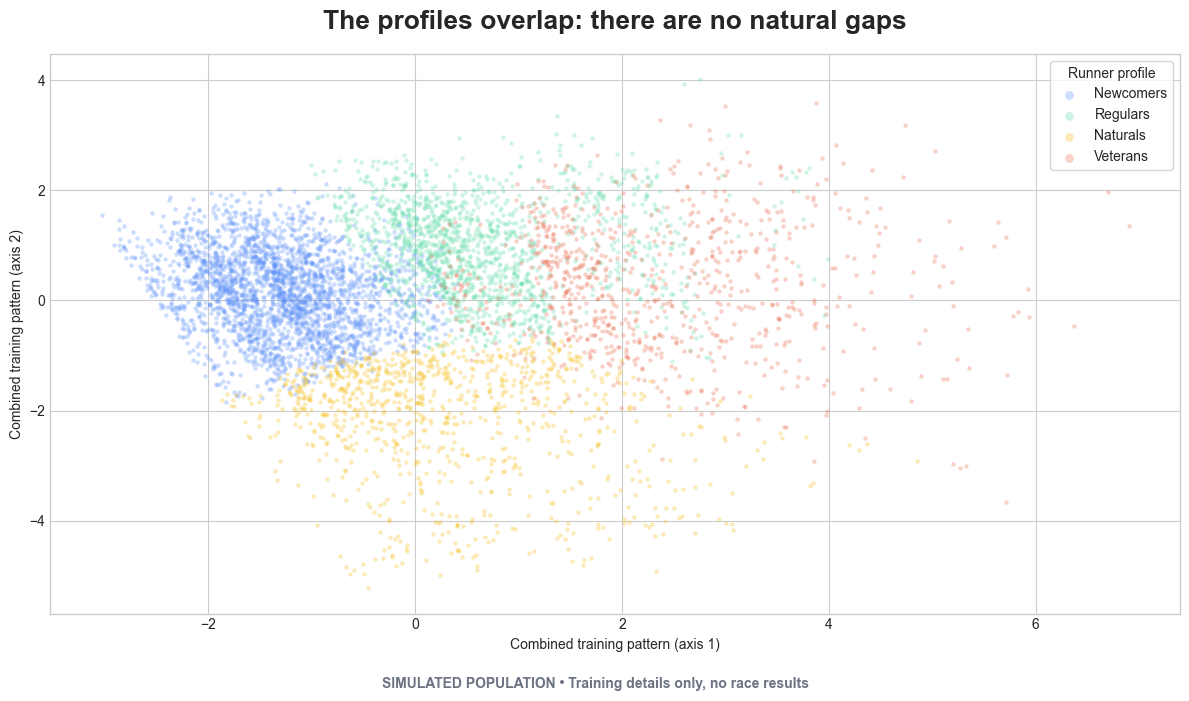

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

BODY = [
    'age', 'running_experience_months', 'previous_marathon_count',
    'weekly_mileage_miles', 'runs_per_week', 'speed_work_sessions_per_week',
    'rest_days_per_week', 'cross_training_hours_per_week',
    'resting_heart_rate_bpm', 'vo2_max', 'bmi', 'injury_count'
]
X_story = StandardScaler().fit_transform(df[BODY])
pca = PCA(n_components=2).fit(X_story)
xy = pca.transform(X_story)
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(df), 6_000, replace=False)

fig, ax = plt.subplots(figsize=(12, 7))
for profile_id in sorted(df['profile'].unique()):
    mask = df['profile'].to_numpy()[sample_idx] == profile_id
    ax.scatter(
        xy[sample_idx[mask], 0], xy[sample_idx[mask], 1],
        s=10, alpha=.30, linewidths=0, color=COLORS[profile_id],
        label=NAME_MAP[profile_id]
    )
ax.set_title('The profiles overlap: there are no natural gaps', fontsize=19, fontweight='bold', pad=18)
ax.set_xlabel('Combined training pattern (axis 1)')
ax.set_ylabel('Combined training pattern (axis 2)')
ax.legend(title='Runner profile', markerscale=2, frameon=True)
fig.text(0.5, 0.01, 'SIMULATED POPULATION \u2022 Training details only, no race results',
         ha='center', fontsize=10, fontweight='bold', color='#6B7280')
plt.tight_layout(rect=[0, .04, 1, 1])
plt.show()

## 2. Fifty-one minutes apart

The gap between the two ends of the profile continuum is large. In this simulated population,
Newcomers finish in about **301 minutes**, Veterans in about **250 minutes** — a difference of
**51 minutes**.

That gap isn't just a side effect of how the groups were built. Finish time and drop-out were
never used to create the profiles — runners were grouped purely by how they trained, and only
afterwards did we look at how they did on race day. Put simply: **we sorted the simulated runners
by how they trained, and the results sorted themselves afterwards.**

The same pattern shows up in who finishes at all. **3.2% of Newcomers didn't finish, in this
simulated population**, against **1.5% of Veterans** — more than twice the rate. The ordering
isn't perfectly clean, though: Naturals actually drop out least of all (**1.4%**), a shade
below the Veterans. It's a broad tendency across the continuum, not a ranking — and it is still
just a comparison, not proof that being a "Newcomer" causes a runner to drop out.

And the groups still overlap — some Newcomers beat some Veterans. What the gap shows is a
population-level pattern, not a rule for any one person: as training shifts from limited
experience toward more experience and higher training load, outcomes shift with it.

Starting is the hard part, and the data agrees. The next question is whether experience is worth
the same amount at every stage, or whether it matters more early on.

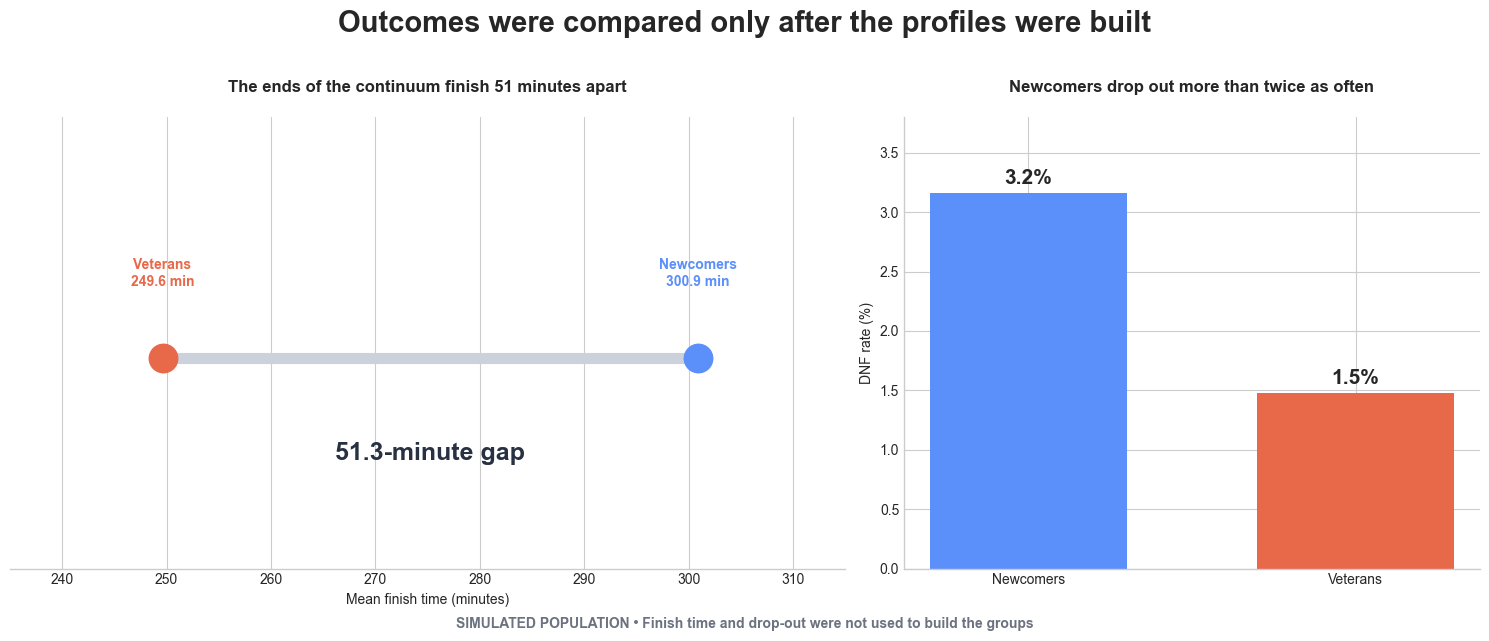

In [4]:
comparison = profile_stats.set_index('profile')
new = comparison.loc[0]
vet = comparison.loc[3]
gap = new['finish_minutes'] - vet['finish_minutes']

fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [1.45, 1]})
fig.patch.set_facecolor('white')

# Finish-time gap
ax = axes[0]
y = 0
ax.plot([vet['finish_minutes'], new['finish_minutes']], [y, y], color='#CBD2DC', lw=8, solid_capstyle='round')
ax.scatter(vet['finish_minutes'], y, s=420, color=COLORS[3], zorder=3, label='Veterans')
ax.scatter(new['finish_minutes'], y, s=420, color=COLORS[0], zorder=3, label='Newcomers')
ax.text(vet['finish_minutes'], y + 0.12, f"Veterans\n{vet['finish_minutes']:.1f} min", ha='center', fontweight='bold', color=COLORS[3])
ax.text(new['finish_minutes'], y + 0.12, f"Newcomers\n{new['finish_minutes']:.1f} min", ha='center', fontweight='bold', color=COLORS[0])
ax.text((vet['finish_minutes'] + new['finish_minutes']) / 2, y - 0.17,
        f"{gap:.1f}-minute gap", ha='center', fontsize=18, fontweight='bold', color='#273142')
ax.set_xlim(235, 315)
ax.set_ylim(-0.35, 0.4)
ax.set_yticks([])
ax.set_xlabel('Mean finish time (minutes)')
ax.set_title('The ends of the continuum finish 51 minutes apart', fontweight='bold', pad=18)
for spine in ['left', 'right', 'top']:
    ax.spines[spine].set_visible(False)

# DNF comparison
ax = axes[1]
labels = ['Newcomers', 'Veterans']
rates = [new['dnf_rate'] * 100, vet['dnf_rate'] * 100]
bars = ax.bar(labels, rates, color=[COLORS[0], COLORS[3]], width=0.6)
ax.bar_label(bars, labels=[f'{v:.1f}%' for v in rates], padding=4, fontsize=15, fontweight='bold')
ax.set_ylim(0, 3.8)
ax.set_ylabel('DNF rate (%)')
ax.set_title('Newcomers drop out more than twice as often', fontweight='bold', pad=18)
ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Outcomes were compared only after the profiles were built', fontsize=21, fontweight='bold', y=1.02)
fig.text(0.5, -0.01, 'SIMULATED POPULATION \u2022 Finish time and drop-out were not used to build the groups',
         ha='center', fontsize=10, fontweight='bold', color='#6B7280')
plt.tight_layout()
plt.show()

### Averages hide the full picture

The 51-minute gap is the distance between group averages. The chart below shows what those
averages hide: faster groups shift toward quicker times overall, but every group still covers a
wide range of outcomes. Being a "Newcomer" or a "Veteran" describes a tendency in this simulated
population — it doesn't decide any individual runner's result.

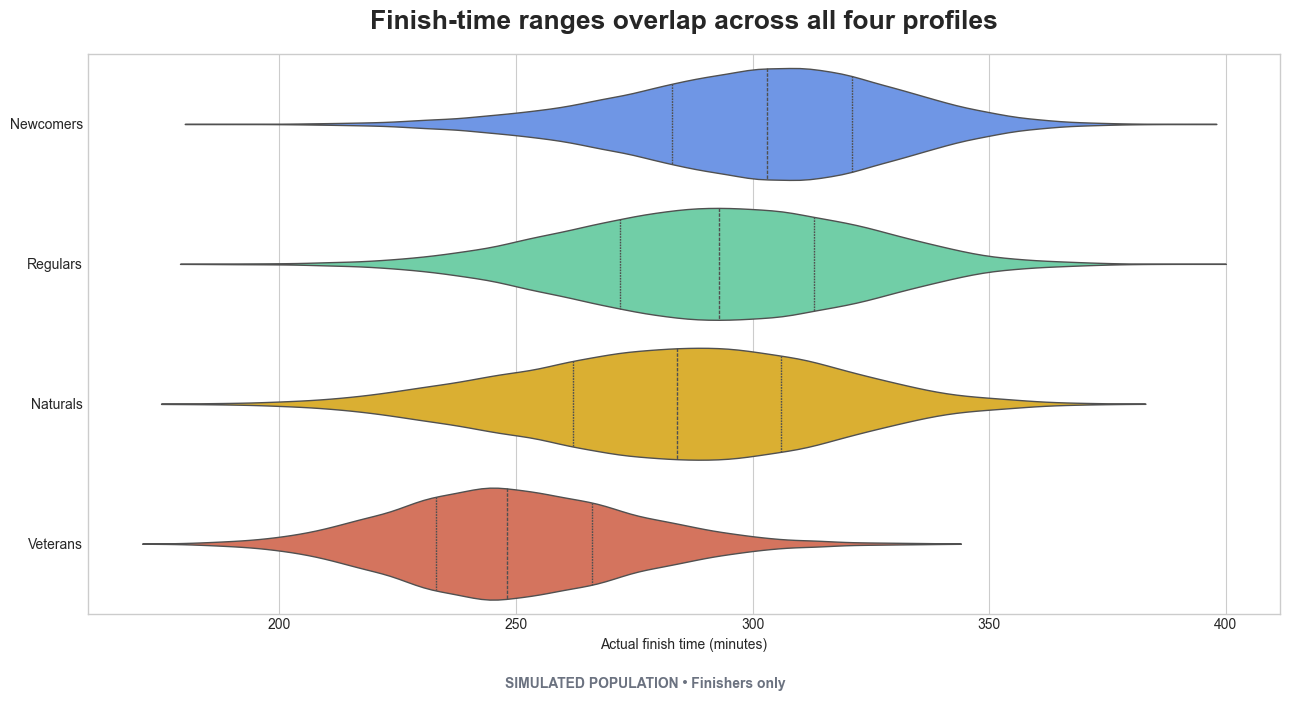

In [5]:
import seaborn as sns

profile_order = ['Newcomers', 'Regulars', 'Naturals', 'Veterans']
palette = [COLORS[i] for i in range(4)]

fig, ax = plt.subplots(figsize=(13, 7))
sns_data = df[df['dnf'] == 0].copy()
sns.violinplot(
    data=sns_data,
    y='profile_name', x='actual_finish_time_minutes',
    order=profile_order, palette=palette,
    hue='profile_name', hue_order=profile_order, legend=False,
    inner='quartile', cut=0, linewidth=1, ax=ax
)
ax.set_title('Finish-time ranges overlap across all four profiles',
             fontsize=19, fontweight='bold', pad=18)
ax.set_xlabel('Actual finish time (minutes)')
ax.set_ylabel('')
fig.text(0.5, 0.01, 'SIMULATED POPULATION \u2022 Finishers only',
         ha='center', fontsize=10, fontweight='bold', color='#6B7280')
plt.tight_layout(rect=[0, .04, 1, 1])
plt.show()

## 3. The first year is the steep part

Section 2 showed how far apart the groups finish. This section asks a more personal question: for
one runner moving through time, when does another year of running matter most? It turns out
experience doesn't pay off at a steady rate — it pays off fastest right at the start, in this
simulated population.

In [6]:
PRED = ['running_experience_months', 'weekly_mileage_miles', 'runs_per_week',
        'speed_work_sessions_per_week', 'cross_training_hours_per_week',
        'resting_heart_rate_bpm', 'vo2_max', 'age', 'injury_count', 'bmi',
        'previous_marathon_count']

def design(frame):
    e = frame.running_experience_months.values
    return np.column_stack([np.ones(len(frame)), frame[PRED].values, e ** 2])

A = design(d)
y = d.actual_finish_time_minutes.values
beta = np.linalg.lstsq(A, y, rcond=None)[0]

def experience_effect(months):
    """minutes SAVED by one more YEAR of running, at a given experience level.

    beta is fitted against finish time, where faster is a smaller number, so the raw derivative
    is negative. Negate it so the figure reads as a payoff rather than a penalty."""
    return -12 * (beta[1] + 2 * beta[-1] * months)

years = pd.DataFrame({
    'experience so far': ['6 months', '1 year', '2 years', '3 years', '5 years', '10 years'],
    'minutes faster from one more year (simulated)':
        [round(experience_effect(m), 1) for m in (6, 12, 24, 36, 60, 120)]
})
years

,experience so far,minutes faster from one more year (simulated)
0,6 months,13.0
1,1 year,12.4
2,2 years,11.3
3,3 years,10.1
4,5 years,7.8
5,10 years,2.0


Someone with one year of running behind them gains about **12 minutes** from a twelfth month, in
this simulated population. By three years, one more year is worth about **10 minutes**. By ten
years, it's worth barely **2 minutes**. The steepest part of the curve sits right at the
beginning — in the stretch a newcomer hasn't run yet.

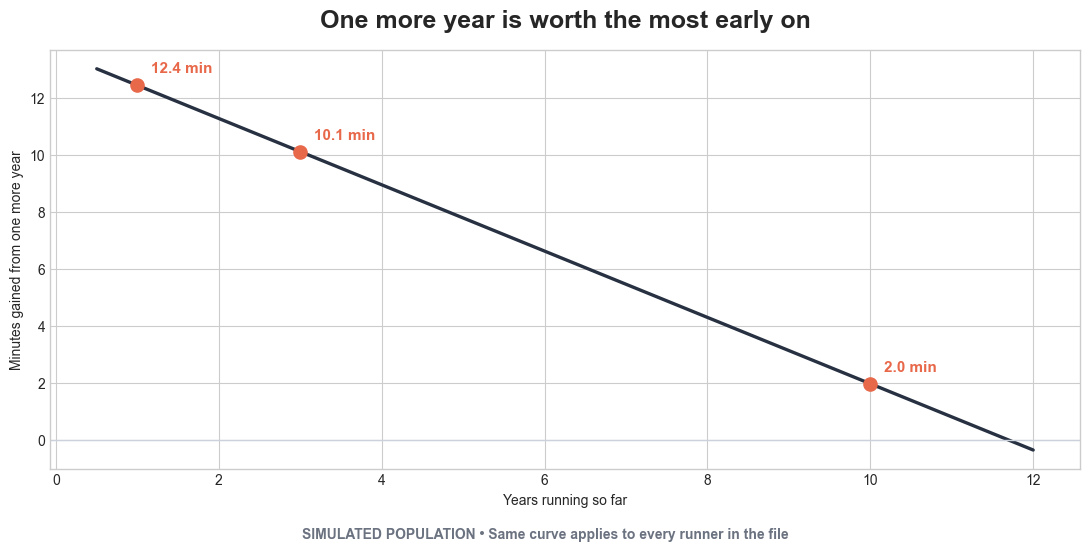

In [7]:
fig, ax = plt.subplots(figsize=(11, 5.5))
ms = np.arange(6, 145)
ax.plot(ms / 12, [experience_effect(m) for m in ms], color=INK, lw=2.4)
ax.axhline(0, color='#CBD2DC', lw=1)
for m in (12, 36, 120):
    v = experience_effect(m)
    ax.scatter(m / 12, v, s=90, color=COLORS[3], zorder=3)
    ax.annotate(f'{v:.1f} min', (m / 12, v), textcoords='offset points', xytext=(10, 9),
                fontsize=11, fontweight='bold', color=COLORS[3])
ax.set_title('One more year is worth the most early on', fontsize=18, fontweight='bold', pad=16)
ax.set_xlabel('Years running so far')
ax.set_ylabel('Minutes gained from one more year')
fig.text(0.5, 0.01, 'SIMULATED POPULATION \u2022 Same curve applies to every runner in the file',
         ha='center', fontsize=10, fontweight='bold', color='#6B7280')
plt.tight_layout(rect=[0, .04, 1, 1])
plt.show()

It's tempting to read this as "training pays off less once you're experienced." That's not quite
right, and it's worth being careful here. When we first compared newcomers and veterans side by
side, it looked like newcomers got a much bigger payoff from experience than veterans did. But
that turned out to be a trick of the curve, not a real difference between the groups: newcomers
and veterans simply sit at different points along the *same* curve, so the newcomer's stretch
naturally looks steeper — it's the early part. Once that was accounted for, the difference between
the groups mostly disappeared.

So the honest takeaway is about timing, not about people: **the payoff from experience slows down
for everyone, at the same rate, as time passes.** It isn't that training pays off less for people
who've already been running longer — it's that any runner's own gains get smaller the longer they
keep going.

### A pattern psychology recognises

*This section was written by Ariella Kaeslin.*

> **SIMULATED POPULATION** — This subsection reads the experience curve above through
> psychological research on skill and habit. It is a lens for interpreting the simulated numbers,
> not a training recommendation.

The shape of this curve — steep at the beginning, flattening out later — is not unique to
running. Newell and Rosenbloom (1981) describe the same pattern across a wide range of tasks:
gains from practice are never linear, improvement is greatest early on, and it slows continuously
as skill accumulates, regardless of the domain. Seen through this lens, the marathon experience
curve in this dataset looks like one instance of a much broader regularity, where how much is
still to be gained depends on how much has already been gained, not on how much effort is
invested.

Research on habit formation tells a similar story. Lally, van Jaarsveld, Potts and Wardle (2010)
tracked real behaviour change over time and found that automaticity — how effortless and routine
an action feels — grows along a curve that levels off: the fastest gains come soon after a
behaviour begins, and for exercise specifically, a plateau is typically reached after a median of
around three months. Applied here, that would place the steepest segment of the experience curve
exactly in the period when running is plausibly still turning from a deliberate decision into a
stable habit. Self-efficacy theory (Bandura, 1977) points to the same window: it's the period in
which confidence in one's own ability to keep the habit going is least settled, and so most
changeable.

One caution matters before taking this any further, though. The dataset is a snapshot, not a
diary: it compares many different runners at different levels of experience rather than following
one runner across the years. Dropout from running also isn't spread evenly across experience
levels — a recent large cohort study of exercise-app users found only around 10% of beginners were
still active after twelve months, against roughly 18% of intermediate and 26% of advanced
exercisers (Conti et al., 2026). If something similar holds among runners, the ten-year group in
this dataset isn't simply the six-month group grown older — it's a group that has already survived
the very period when most people who start running stop again. The flattening of the curve at
higher experience levels can be read two ways that this dataset alone can't tell apart: a genuine
slowing of returns to practice, or a shift in who is even left to be measured. Both readings fit
the same simulated numbers. Neither should be turned into a recommendation for how anyone ought to
train. (Bandura, 1977; Conti et al., 2026; Lally et al., 2010; Newell & Rosenbloom, 1981 &mdash;
full references at the end of this notebook.)

## 4. What else moved the clock

Experience matters most, but a few other everyday changes also shift the same model's prediction,
each considered on its own, in this simulated population.

In [8]:
LABELS = {
    'speed_work_sessions_per_week': 'One extra speed session per week',
    'runs_per_week': 'One extra run per week',
    'weekly_mileage_miles': 'One extra mile per week',
    'injury_count': 'One more injury during training',
}
effects = (pd.Series(beta[1:len(PRED) + 1], index=PRED)
             .loc[list(LABELS)]
             .rename(index=LABELS)
             .round(1)
             .sort_values())
effects.to_frame('change in finish time (minutes, simulated)')

,"change in finish time (minutes, simulated)"
One extra speed session per week,-2.2
One extra run per week,-1.5
One extra mile per week,-0.3
One more injury during training,6.7


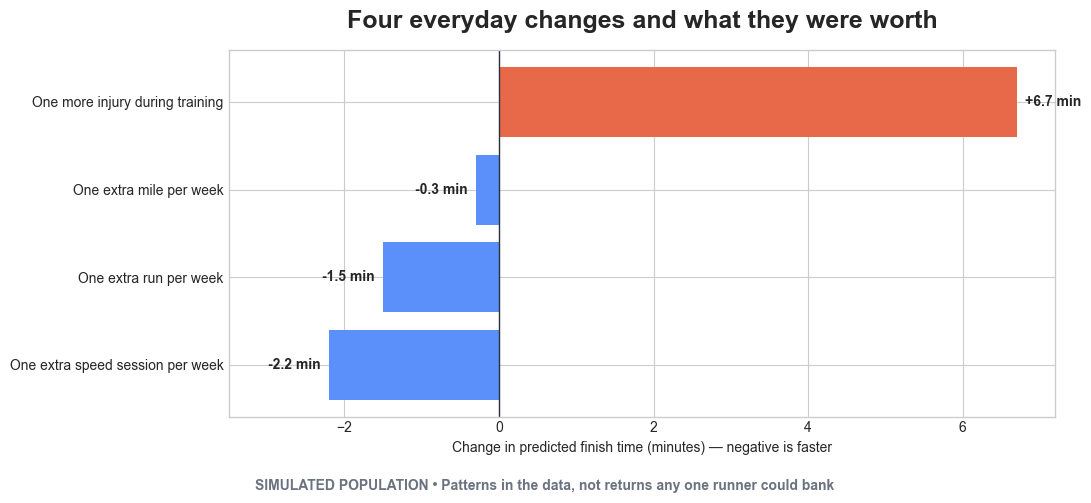

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))
colors = [COLORS[3] if v > 0 else COLORS[0] for v in effects.values]
bars = ax.barh(effects.index, effects.values, color=colors)
ax.set_xlim(-3.5, 7.2)
ax.bar_label(bars, labels=[f'{v:+.1f} min' for v in effects.values], padding=6, fontweight='bold')
ax.axvline(0, color=INK, lw=1)
ax.set_xlabel('Change in predicted finish time (minutes) — negative is faster')
ax.set_title('Four everyday changes and what they were worth', fontsize=18, fontweight='bold', pad=16)
fig.text(0.5, 0.01, 'SIMULATED POPULATION \u2022 Patterns in the data, not returns any one runner could bank',
         ha='center', fontsize=10, fontweight='bold', color='#6B7280')
plt.tight_layout(rect=[0, .05, 1, 1])
plt.show()

One extra speed session a week is worth about **2 minutes**, one extra run a week about **1.5
minutes**, and one extra mile of weekly distance only about **0.3 minutes** — all in this
simulated population. One more injury during training costs about **7 minutes**, easily the
biggest single hit on the list, bigger than a whole week of extra training buys back.

These are patterns in a simulated population, not returns any real runner could bank. Adding a
weekly speed session doesn't hand anyone two minutes; the number describes a tendency across
80,000 simulated rows, not a promise about one training plan. Plenty of other things we measured
barely moved the prediction at all — which raises the next question: how much of any of this
should we actually believe?

## 5. Then we checked whether to believe it

Everything so far took the dataset at its word. This section does the opposite — it asks the file
to explain itself.

In [10]:
from scipy import stats
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

GREY5 = '#8C8C8C'
RS = 0

# drop-outs have no finish time, so they sit out of every model here
sec5 = clean[clean.dnf == 0].copy()
print(f'{len(sec5):,} finishers go into this section')

78,011 finishers go into this section


### Most of what we measured turned out not to matter

A few things move finish time the way real running would predict: more experience means a faster
time, more injuries mean a slower one, a lower resting heart rate means a faster one. Those are
the three the earlier sections leaned on.

But the file also records dozens of other things — sleep, nutrition, motivation, recovery, how
often someone shows up to club runs. To find out what each of those was actually worth, we built a
model that predicts finish time from everything at once, then scrambled one column at a time to
see how much worse the model got. If scrambling a column barely hurts it, that column wasn't doing
much in the first place.

In [11]:
# same input set as 06, so the numbers line up with the earlier notebooks
SPOILERS = ['actual_finish_time_minutes', 'target_finish_time_minutes', 'goal_gap', 'dnf',
            'medal', 'medal_outcome', 'runner_id', 'personal_best_minutes']

# one of each mirrored pair: rest_days = 7 - runs_per_week, missed workouts mirror adherence,
# VO2 max mirrors resting heart rate
DUPES = ['rest_days_per_week', 'missed_workout_pct', 'vo2_max']

IN = [c for c in clean.select_dtypes('number').columns
      if c not in SPOILERS + DUPES and not c.endswith('_was_missing')]

X5, y5 = sec5[IN].values, sec5.actual_finish_time_minutes.values
Xtr, Xte, ytr, yte = train_test_split(X5, y5, test_size=0.25, random_state=RS)

# constrained to a sum of per-variable terms: no interactions allowed
additive = HistGradientBoostingRegressor(
    max_iter=300, random_state=RS,
    interaction_cst=[[i] for i in range(X5.shape[1])]).fit(Xtr, ytr)

imp = permutation_importance(additive, Xte, yte, n_repeats=3, random_state=RS, scoring='r2')
importance = pd.Series(imp.importances_mean, index=IN).sort_values(ascending=False)

ratio = importance.iloc[0] / importance.iloc[1:].sum()
print(f'{(importance <= 0.0005).sum()} of {len(IN)} things tested made almost no difference')
print(f'experience is worth about {ratio:.0f}x everything else put together')
importance.head(8).round(4).rename('how much accuracy drops when scrambled')

19 of 28 things tested made almost no difference
experience is worth about 13x everything else put together


running_experience_months    1.0726
injury_count                 0.0512
resting_heart_rate_bpm       0.0246
recovery_score               0.0029
weekly_mileage_miles         0.0017
nutrition_score              0.0013
run_club_attendance_rate     0.0010
training_adherence_pct       0.0009
Name: how much accuracy drops when scrambled, dtype: float64

Running experience turned out to be worth roughly thirteen times as much as everything else put
together. Injuries and resting heart rate added a little on top. Below that, **19 of the 28 things
we tested made almost no difference at all** — sleep, motivation, nutrition, recovery, club
attendance, and more.

Weekly mileage is one of those columns that barely mattered, and that detail gives the file away.
In real marathon research, weekly mileage is one of the single strongest predictors of finish time
there is. A dataset where it does almost nothing isn't just an unusual dataset about running — it
looks like it isn't really about running at all. It looks like it's about whatever process built
the file.

### What actually built the file

Once you go looking, the file gives itself away in three ways.

**Every factor works on its own, with no teamwork between them.** We tested whether letting the
model combine factors in clever ways — say, mileage mattering more for veterans than for
newcomers — made any real difference to its accuracy. It didn't. Every input in this file simply
adds or subtracts its own fixed number of minutes, independently of everything else.

In [12]:
unconstrained = HistGradientBoostingRegressor(max_iter=300, random_state=RS).fit(Xtr, ytr)

gain = unconstrained.score(Xte, yte) - additive.score(Xte, yte)
print(f'model that keeps every factor separate:   explains {additive.score(Xte, yte):.1%} of the variation')
print(f'model allowed to mix factors together:     explains {unconstrained.score(Xte, yte):.1%} of the variation')
print(f'difference from allowing mixing:           {gain:+.2%}  (essentially nothing)')

model that keeps every factor separate:   explains 60.6% of the variation
model allowed to mix factors together:     explains 60.7% of the variation
difference from allowing mixing:           +0.04%  (essentially nothing)


**What's left over looks like static.** After accounting for experience, injuries and the rest,
there's still a gap between the model's guess and the real number — averaging about 21 minutes in
either direction. That gap has no pattern to it: it's just as large for fast runners as for slow
ones, and shaped exactly like textbook random noise. It looks like what you'd see if about 21
minutes were added to, or subtracted from, every runner's time by a random number generator —
because that's what it is.

In [13]:
resid = yte - additive.predict(Xte)

print(f'typical size of the leftover gap:  {resid.std():.0f} minutes')
print(f'lopsided in one direction?         {stats.skew(resid):+.2f}   (0 = perfectly balanced)')
print(f'odd spikes or heavy tails?         {stats.kurtosis(resid):+.2f}   (0 = plain bell curve)')

spread = (pd.Series(resid)
            .groupby(pd.qcut(additive.predict(Xte), 5, labels=['fastest', '2', '3', '4', 'slowest']),
                     observed=True)
            .std().round(2))
spread.rename('typical gap size, fastest runners to slowest')

typical size of the leftover gap:  21 minutes
lopsided in one direction?         +0.02   (0 = perfectly balanced)
odd spikes or heavy tails?         -0.01   (0 = plain bell curve)


fastest    21.19
2          21.01
3          20.80
4          20.87
slowest    21.74
Name: typical gap size, fastest runners to slowest, dtype: float64

**The numbers look manufactured, not measured.** Real training data is messy — no two runners
report exactly the same weekly mileage down to the decimal. In this file, half of all runners
share the *exact* same weekly mileage number, and four out of five share the exact same longest
training run. That's not what you'd expect from tracking real people. It's what you'd expect from
generating numbers by computer and cutting off any that went past a limit.

That also closes the loop on the first clue. Weekly mileage didn't look like it mattered partly
because, for half the file, it doesn't vary at all — a column pinned to its floor for 40,000
runners leaves a model very little variation to find an effect in. The flat importance score and
the manufactured-looking numbers aren't two separate oddities; the second helps produce the first.

In [14]:
BOUNDED = ['vo2_max', 'resting_heart_rate_bpm', 'bmi', 'sleep_hours_avg',
           'training_adherence_pct', 'weekly_mileage_miles', 'long_run_distance_km']

bounds = pd.DataFrame({
    'min': clean[BOUNDED].min(),
    'max': clean[BOUNDED].max(),
    'share stuck at the minimum': (clean[BOUNDED] == clean[BOUNDED].min()).mean().round(2),
})
bounds

,min,max,share stuck at the minimum
vo2_max,35.0,75.0,0.01
resting_heart_rate_bpm,45.0,80.0,0.00
bmi,18.0,32.0,0.04
sleep_hours_avg,5.0,10.0,0.02
training_adherence_pct,40.0,100.0,0.00
weekly_mileage_miles,12.4,60.2,0.50
long_run_distance_km,15.0,41.2,0.81


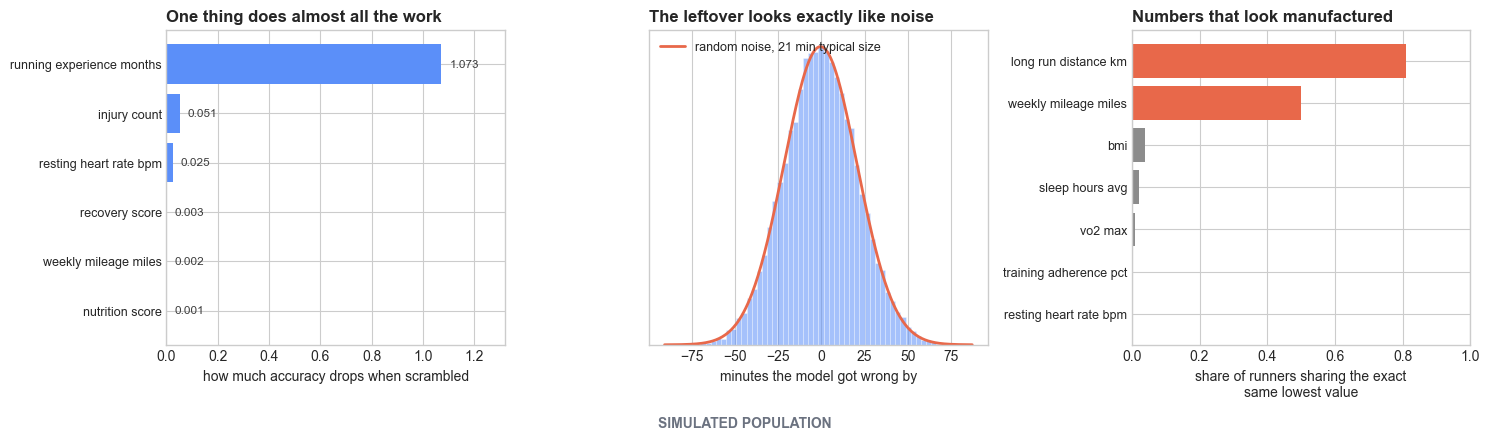

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
fig.patch.set_facecolor('white')

# A - what each thing was worth
ax = axes[0]
top = importance.head(6)[::-1]
ax.barh(range(len(top)), top.values,
        color=[COLORS[0] if v > 0.01 else GREY5 for v in top.values])
for i, v in enumerate(top.values):
    ax.text(v + .03, i, f'{v:.3f}', va='center', fontsize=8.5, color='#3C3C3C')
ax.set_yticks(range(len(top)))
ax.set_yticklabels([c.replace('_', ' ') for c in top.index], fontsize=9)
ax.set_xlim(0, 1.32)
ax.set_xlabel('how much accuracy drops when scrambled')
ax.set_title('One thing does almost all the work', loc='left', fontweight='bold')

# B - the leftover
ax = axes[1]
ax.hist(resid, bins=60, density=True, color=COLORS[0], alpha=.55, edgecolor='white', linewidth=.4)
grid = np.linspace(resid.min(), resid.max(), 300)
ax.plot(grid, stats.norm.pdf(grid, resid.mean(), resid.std()), color=COLORS[3], lw=2,
        label=f'random noise, {resid.std():.0f} min typical size')
ax.set_xlabel('minutes the model got wrong by')
ax.set_yticks([])
ax.legend(frameon=False, fontsize=9, loc='upper left')
ax.set_title('The leftover looks exactly like noise', loc='left', fontweight='bold')

# C - the clipping
ax = axes[2]
share = bounds['share stuck at the minimum'].sort_values()
ax.barh(range(len(share)), share.values,
        color=[COLORS[3] if v > .2 else GREY5 for v in share.values])
ax.set_yticks(range(len(share)))
ax.set_yticklabels([c.replace('_', ' ') for c in share.index], fontsize=9)
ax.set_xlim(0, 1)
ax.set_xlabel('share of runners sharing the exact\nsame lowest value')
ax.set_title('Numbers that look manufactured', loc='left', fontweight='bold')

fig.text(0.5, -0.03, 'SIMULATED POPULATION',
         ha='center', fontsize=10, fontweight='bold', color='#6B7280')
fig.tight_layout()
FIG.mkdir(exist_ok=True)
fig.savefig(FIG / 'section5_generator.png', dpi=150, bbox_inches='tight')
plt.show()

### Put together

One sentence covers it: build each runner's stats independently and cut off the extremes, work
out a finish time that's mostly just experience plus a few small adjustments, sprinkle about 21
minutes of pure randomness on top, then quietly set a target time by shaving a bit off the real
result.

That one sentence explains everything that seemed odd. Most of what we measured didn't matter
because it was never part of the formula. The four profiles don't behave differently from each
other because there's no teamwork between factors for a formula like this to produce. No model
gets much closer than it already does — about 18 minutes of *average* error in our modelling notebook, against
the 21-minute spread printed above — because roughly 21 minutes of every runner's time comes
straight from a random number generator. And nobody beats their own target by much, because the
target was built from the result instead of set before the race.

None of this makes Sections 1 to 4 wrong — they describe the file honestly. It just means the file
is describing itself, not marathon running.

*(For what it's worth: real studies of marathon training consistently find weekly mileage to be
one of the strongest predictors of finish time there is — the opposite of what this file shows
(Doherty et al., 2020). Full reference at the end of this notebook.)*

## 6. What a synthetic runner can and cannot tell you

Step back, and the dataset produced something that feels believable: four distinct-looking types
of runner, a real gap between the fastest and slowest, a drop-out pattern that lines up with less
experience, and an improvement curve that's steep at first and flattens out later. Every one of
those shapes looks like what you'd expect from real marathon data.

Section 5 is why none of it can be trusted as a fact about running. More than half of what we
measured had no real bearing on finish time. And the file gets one of running's best-established
truths backwards: weekly mileage, which real studies show matters enormously, barely matters here.
A file that gets that wrong isn't a file that happens to disagree with the science — it's a file
that was never built to agree with it. It was built from a formula: mostly experience, a handful
of small adjustments, and a good amount of randomness.

That's not a flaw to apologise for — it's simply what this kind of dataset is for. A well-built
synthetic population can teach you what a marathon story looks like: the shape of a group of
runners, the shape of a drop-out curve, the shape of getting better over time. It cannot teach you
what's actually true about marathon running, because the truth about running was never built into
how the numbers were generated.

**A synthetic dataset can teach you what a story looks like. It cannot tell you what is true.**
Both halves of that matter, and neither one cancels the other out.

## References

Bandura, A. (1977). Self-efficacy: Toward a unifying theory of behavioral change. *Psychological
Review*, 84(2), 191&ndash;215. https://doi.org/10.1037/0033-295X.84.2.191

Conti, F., Marzagão, T., Galpin, A. J., & Schoenfeld, B. J. (2026). Predictors of long-term
resistance exercise adherence: Evidence from a large cohort of mobile app users of various
experience levels. *Frontiers in Sports and Active Living*, 8.
https://doi.org/10.3389/fspor.2026.1855668

Doherty, C., Keogh, A., Davenport, J., Lawlor, A., Smyth, B., & Caulfield, B. (2020). An
evaluation of the training determinants of marathon performance: a meta-analysis with
meta-regression. *Journal of Science and Medicine in Sport*, 23(2), 182&ndash;188.
https://doi.org/10.1016/j.jsams.2019.09.013

Lally, P., van Jaarsveld, C. H. M., Potts, H. W. W., & Wardle, J. (2010). How are habits formed:
Modelling habit formation in the real world. *European Journal of Social Psychology*, 40(6),
998&ndash;1009. https://doi.org/10.1002/ejsp.674

Newell, A., & Rosenbloom, P. S. (1981). Mechanisms of skill acquisition and the law of practice.
In J. R. Anderson (Ed.), *Cognitive skills and their acquisition* (pp. 1&ndash;55). Lawrence
Erlbaum Associates.